In [1]:
%pip install -q pandas numpy scikit-learn matplotlib seaborn pyarrow statsmodels

Note: you may need to restart the kernel to use updated packages.


In [2]:
#Setup
#Loading the libraries we need. Pandas for data handling, sklearn for the models, matplotlib and seaborn for plots.

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve, ConfusionMatrixDisplay)
from statsmodels.stats.contingency_tables import mcnemar

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 50)

In [5]:
#Loading the dataset

In [6]:
df = pd.read_parquet('data/qld_health_analysis.parquet')
print('Shape:', df.shape)
df.head()

Shape: (276360, 20)


,year,state_name,geog_type_name,geog_id,sa4_code,sa4_name,sa3_code,sa3_name,sa2_code,sa2_name,PHN_NAME_2023,sex_name,age_group,age_group_label,long_term_health_condition,persons,state,geog_type,sex,lthc
0,2021,Queensland,Statistical Area Level 2,302041042,302,Brisbane - North,30204,Sandgate,302041042,Brighton (Qld),Brisbane North,Persons,75_84,75-84 years,Total (Persons),484,3,SA2,3,_T
1,2021,Queensland,Statistical Area Level 2,302041044,302,Brisbane - North,30204,Sandgate,302041044,Sandgate - Shorncliffe,Brisbane North,Persons,35_44,35-44 years,No long-term health condition(s),470,3,SA2,3,121
2,2021,Queensland,Statistical Area Level 2,303011048,303,Brisbane - South,30301,Carindale,303011048,Cannon Hill,Brisbane South,Males,_T,Total,Dementia (including Alzheimer's),4,3,SA2,1,41
3,2021,Queensland,Statistical Area Level 2,304021090,304,Brisbane - West,30402,Kenmore - Brookfield - Moggill,304021090,Kenmore,Brisbane North,Females,45_54,45-54 years,Asthma,76,3,SA2,2,21
4,2021,Queensland,Statistical Area Level 2,305031127,305,Brisbane Inner City,30503,Brisbane Inner - North,305031127,Newmarket,Brisbane North,Persons,GE85,85 plus,Total (Persons),43,3,SA2,3,_T


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276360 entries, 0 to 276359
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   year                        276360 non-null  int32 
 1   state_name                  276360 non-null  object
 2   geog_type_name              276360 non-null  object
 3   geog_id                     276360 non-null  object
 4   sa4_code                    274260 non-null  object
 5   sa4_name                    274260 non-null  object
 6   sa3_code                    265440 non-null  object
 7   sa3_name                    265440 non-null  object
 8   sa2_code                    230160 non-null  object
 9   sa2_name                    230160 non-null  object
 10  PHN_NAME_2023               229320 non-null  object
 11  sex_name                    276360 non-null  object
 12  age_group                   276360 non-null  object
 13  age_group_label             2

In [8]:
print('Geography levels:')
print(df['geog_type_name'].value_counts())
print()
print('Conditions:')
for c in df['long_term_health_condition'].unique():
    print(' -', c)
print()
print('Ages:', sorted(df['age_group'].unique()))
print('Sex:', df['sex_name'].unique().tolist())
print('Year:', df['year'].unique().tolist())
print('State:', df['state_name'].unique().tolist())

Geography levels:
geog_type_name
Statistical Area Level 2                  230160
Statistical Area Level 3                   35280
Statistical Area Level 4                    8820
Greater Capital City Statistical Areas      1680
States and Territories                       420
Name: count, dtype: int64

Conditions:
 - Total (Persons)
 - No long-term health condition(s)
 - Dementia (including Alzheimer's)
 - Asthma
 - Mental health condition (including depression or anxiety)
 - Not stated
 - Arthritis
 - Lung condition (including COPD or emphysema)
 - Any other long-term health condition(s)
 - Cancer (including remission)
 - Stroke
 - Kidney disease
 - Heart disease (including heart attack or angina)
 - Diabetes (excluding gestational diabetes)

Ages: ['0_14', '15_24', '25_34', '35_44', '45_54', '55_64', '65_74', '75_84', 'GE85', '_T']
Sex: ['Persons', 'Males', 'Females']
Year: [2021]
State: ['Queensland']


In [9]:
#Checking for missing values

In [10]:
nulls = df.isna().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
print('Columns with missing values:')
print(nulls)

Columns with missing values:
PHN_NAME_2023    47040
sa2_code         46200
sa2_name         46200
sa3_code         10920
sa3_name         10920
sa4_code          2100
sa4_name          2100
dtype: int64


In [11]:
sa2_only = df[df['geog_type_name'] == 'Statistical Area Level 2']
sa2_nulls = sa2_only.isna().sum()
sa2_nulls = sa2_nulls[sa2_nulls > 0]
print('Nulls remaining in SA2-only subset:')
print(sa2_nulls if len(sa2_nulls) else 'None')

Nulls remaining in SA2-only subset:
PHN_NAME_2023    840
dtype: int64


In [12]:
#Filtering and reshaping

In [13]:
sa2 = df[df['geog_type_name'] == 'Statistical Area Level 2'].copy()
sa2 = sa2[(sa2['age_group'] != '_T') & (sa2['sex_name'] != 'Persons')]
sa2 = sa2.drop(columns=['year', 'state', 'state_name', 'geog_type', 'geog_type_name',
                        'sex', 'lthc', 'age_group_label'])
print('After filtering:', sa2.shape)

After filtering: (138096, 12)


In [14]:
index_cols = ['sa2_code', 'sa2_name', 'sa3_code', 'sa3_name',
              'sa4_code', 'sa4_name', 'PHN_NAME_2023',
              'geog_id', 'age_group', 'sex_name']

wide = sa2.pivot_table(index=index_cols,
                       columns='long_term_health_condition',
                       values='persons',
                       aggfunc='sum').reset_index()
wide.columns.name = None
print('Wide shape:', wide.shape)
wide.head()

Wide shape: (9828, 24)


,sa2_code,sa2_name,sa3_code,sa3_name,sa4_code,sa4_name,PHN_NAME_2023,geog_id,age_group,sex_name,Any other long-term health condition(s),Arthritis,Asthma,Cancer (including remission),Dementia (including Alzheimer's),Diabetes (excluding gestational diabetes),Heart disease (including heart attack or angina),Kidney disease,Lung condition (including COPD or emphysema),Mental health condition (including depression or anxiety),No long-term health condition(s),Not stated,Stroke,Total (Persons)
0,301011001,Alexandra Hills,30101,Capalaba,301,Brisbane - East,Brisbane South,301011001,0_14,Females,70,0,108,4,0,3,0,3,0,41,1245,109,0,1562
1,301011001,Alexandra Hills,30101,Capalaba,301,Brisbane - East,Brisbane South,301011001,0_14,Males,112,5,129,4,0,4,3,0,6,68,1243,147,0,1678
2,301011001,Alexandra Hills,30101,Capalaba,301,Brisbane - East,Brisbane South,301011001,15_24,Females,52,0,94,0,0,5,0,0,0,160,585,69,0,909
3,301011001,Alexandra Hills,30101,Capalaba,301,Brisbane - East,Brisbane South,301011001,15_24,Males,53,0,100,4,0,4,0,4,3,105,750,83,0,1055
4,301011001,Alexandra Hills,30101,Capalaba,301,Brisbane - East,Brisbane South,301011001,25_34,Females,115,22,122,7,0,17,9,0,4,187,661,69,0,1094


In [ ]:
#Feature engineering

In [15]:
TOTAL = 'Total (Persons)'
MENTAL = 'Mental health condition (including depression or anxiety)'

before = len(wide)
wide = wide[wide[TOTAL] > 0].copy()
print(f'Dropped {before - len(wide)} zero-population cells. Now have {len(wide)}.')

# physical conditions (everything except total, mental, not stated, no condition)
physical = [c for c in wide.columns if c not in index_cols
            and c not in {TOTAL, MENTAL, 'Not stated', 'No long-term health condition(s)'}]

# convert counts to rates
for c in physical + [MENTAL]:
    wide[f'rate__{c}'] = wide[c] / wide[TOTAL]

rate_phys = [f'rate__{c}' for c in physical]

Dropped 268 zero-population cells. Now have 9560.


In [16]:
wide['comorbidity_load'] = wide[rate_phys].sum(axis=1)
wide['comorbidity_count_high'] = (wide[rate_phys] > wide[rate_phys].median()).sum(axis=1)
wide['log_population'] = np.log1p(wide[TOTAL])

age_mid = {'0_14': 7, '15_24': 19.5, '25_34': 29.5, '35_44': 39.5,
           '45_54': 49.5, '55_64': 59.5, '65_74': 69.5, '75_84': 79.5, 'GE85': 90}
wide['age_midpoint'] = wide['age_group'].map(age_mid)

wide[['comorbidity_load', 'comorbidity_count_high', 'log_population', 'age_midpoint']].describe()

,comorbidity_load,comorbidity_count_high,log_population,age_midpoint
count,9560.000000,9560.000000,9560.000000,9560.000000
mean,0.595921,4.809310,5.926888,49.212762
std,0.503443,3.866581,1.003455,26.306917
min,0.000000,0.000000,1.386294,7.000000
25%,0.173453,1.000000,5.497168,29.500000
50%,0.382931,5.000000,6.113682,49.500000
75%,0.988694,9.000000,6.597146,69.500000
max,3.428571,10.000000,8.205765,90.000000


In [17]:
sa4_mean = (wide.groupby('sa4_code')[rate_phys].mean()
                .add_prefix('sa4_mean_').reset_index())
sa4_pop = (wide.groupby('sa4_code')[TOTAL].sum()
              .reset_index().rename(columns={TOTAL: 'sa4_total_pop'}))
sa4_pop['sa4_log_population'] = np.log1p(sa4_pop['sa4_total_pop'])
sa4_pop = sa4_pop.drop(columns=['sa4_total_pop'])

wide = wide.merge(sa4_mean, on='sa4_code').merge(sa4_pop, on='sa4_code')

sa4_cols = [c for c in wide.columns if c.startswith('sa4_mean_') or c == 'sa4_log_population']
print(f'Added {len(sa4_cols)} SA4 regional features.')

Added 11 SA4 regional features.


In [18]:
mh_rate = wide[f'rate__{MENTAL}']
threshold = mh_rate.median()
wide['target_high_mh'] = (mh_rate > threshold).astype(int)

print(f'QLD median MH rate (threshold): {threshold:.4f}')
print(wide['target_high_mh'].value_counts(normalize=True).round(3))

QLD median MH rate (threshold): 0.0909
target_high_mh
0    0.502
1    0.498
Name: proportion, dtype: float64


## Exploratory data analysis


Looking at how mental health rate is distributed and confirming the class balance.

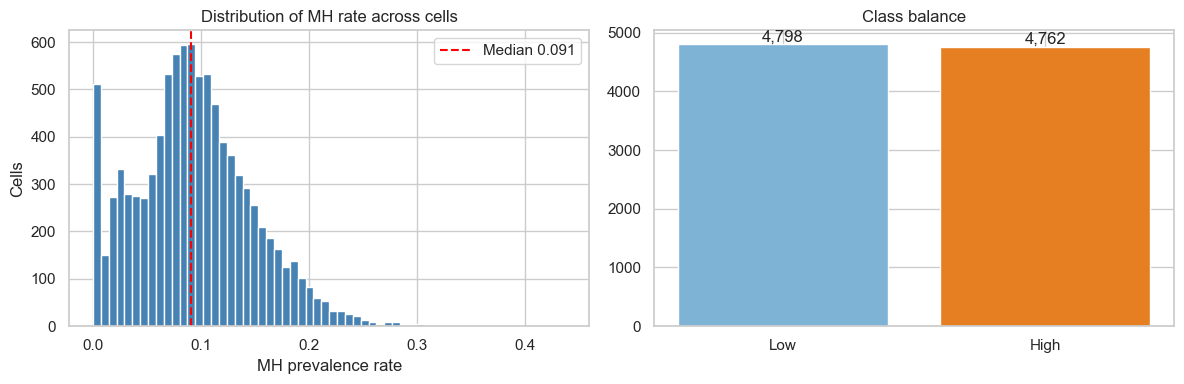

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(mh_rate, bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(threshold, color='red', linestyle='--', label=f'Median {threshold:.3f}')
axes[0].set_xlabel('MH prevalence rate')
axes[0].set_ylabel('Cells')
axes[0].set_title('Distribution of MH rate across cells')
axes[0].legend()

counts = wide['target_high_mh'].value_counts().sort_index()
axes[1].bar(['Low', 'High'], counts.values, color=['#7fb3d5', '#e67e22'])
axes[1].set_title('Class balance')
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 50, f'{v:,}', ha='center')
plt.tight_layout()
plt.show()

Classes are balanced as expected. The distribution is right-skewed with a long tail of small cells with very high rates.

## MH rate by age and sex

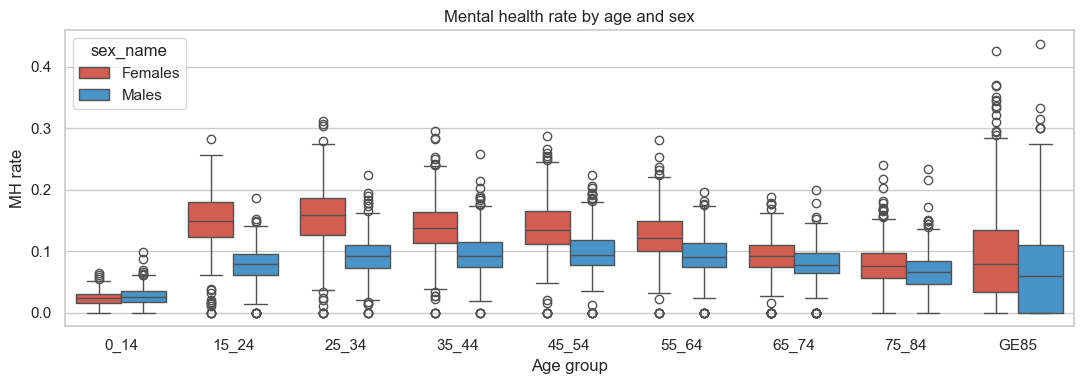

In [20]:
fig, ax = plt.subplots(figsize=(11, 4))
age_order = ['0_14', '15_24', '25_34', '35_44', '45_54', '55_64', '65_74', '75_84', 'GE85']
sns.boxplot(data=wide, x='age_group', y=f'rate__{MENTAL}', hue='sex_name',
            order=age_order, ax=ax, palette={'Females': '#e74c3c', 'Males': '#3498db'})
ax.set_xlabel('Age group')
ax.set_ylabel('MH rate')
ax.set_title('Mental health rate by age and sex')
plt.tight_layout()
plt.show()

Mental health rates peak in young-to-middle-adult women and stay low in children. Matches published Australian patterns. Age and sex are likely going to be strong predictors.

### Correlations with mental health

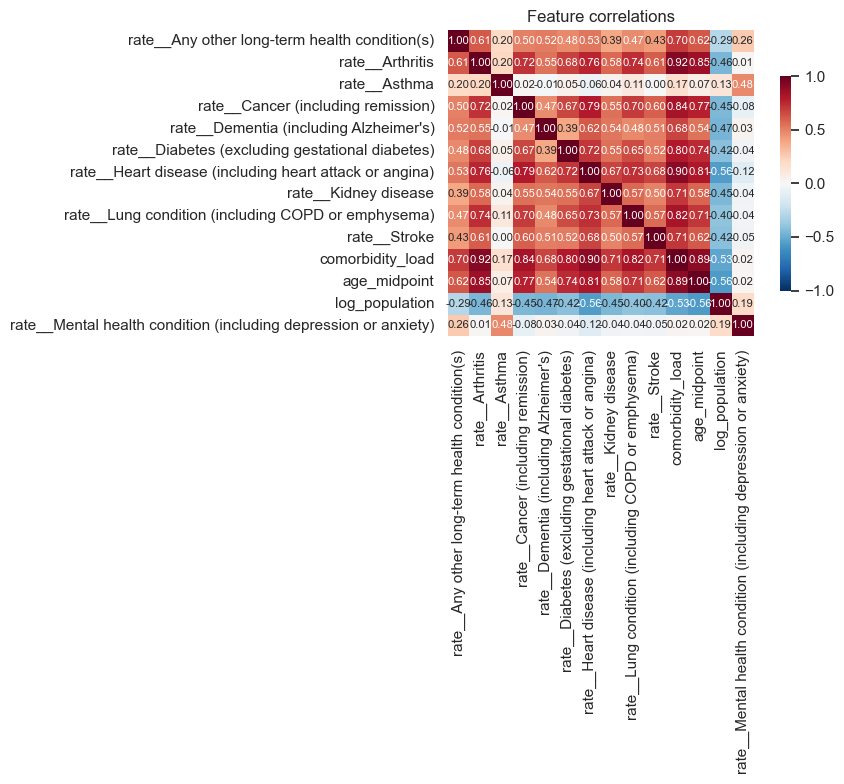

Top correlations with MH rate:
rate__Asthma                                              0.481
rate__Any other long-term health condition(s)             0.259
log_population                                            0.192
rate__Heart disease (including heart attack or angina)    0.119
rate__Cancer (including remission)                        0.083
Name: rate__Mental health condition (including depression or anxiety), dtype: float64


In [21]:
corr_features = rate_phys + ['comorbidity_load', 'age_midpoint', 'log_population']
corr = wide[corr_features + [f'rate__{MENTAL}']].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={'shrink': 0.7}, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Feature correlations')
plt.tight_layout()
plt.show()

top = (corr[f'rate__{MENTAL}'].drop(f'rate__{MENTAL}').abs()
       .sort_values(ascending=False).head())
print('Top correlations with MH rate:')
print(top.round(3))

Asthma is the strongest individual correlate (about 0.48), which lines up with research on asthma-anxiety comorbidity. Other condition rates have weaker but mostly positive correlations.

## Regional variation (SA4)

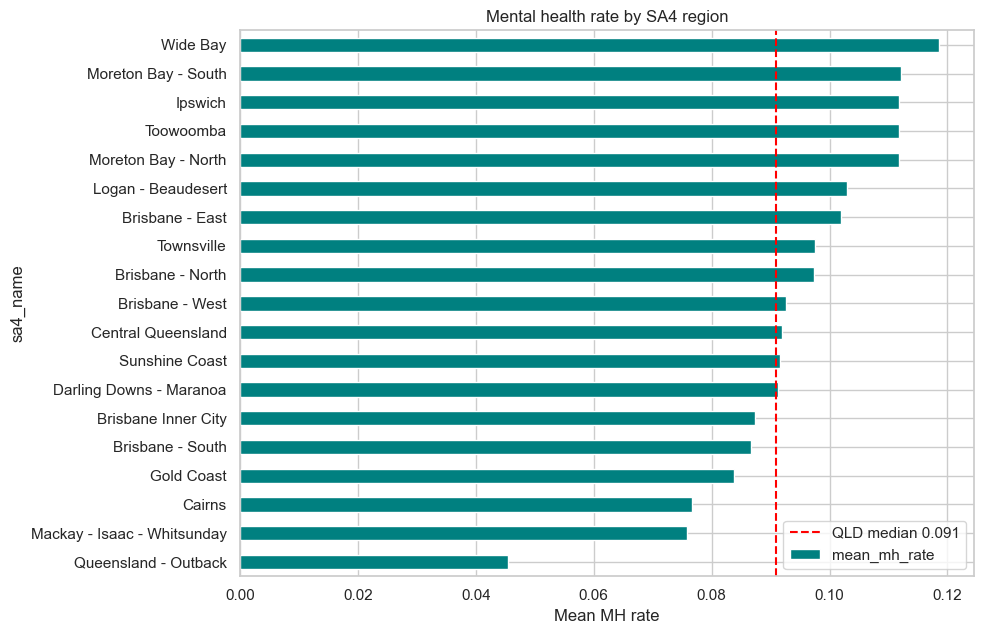

,mean_mh_rate,n_cells,pct_high
sa4_name,,,
Wide Bay,0.1186,616,0.6818
Moreton Bay - South,0.1121,270,0.6037
Ipswich,0.1118,595,0.6286
Toowoomba,0.1117,270,0.6593
Moreton Bay - North,0.1117,393,0.6463
Logan - Beaudesert,0.1030,612,0.5882
Brisbane - East,0.1020,380,0.5605
Townsville,0.0975,592,0.5608
Brisbane - North,0.0973,442,0.5385


In [22]:
sa4_summary = (wide.groupby('sa4_name')
                    .agg(mean_mh_rate=(f'rate__{MENTAL}', 'mean'),
                         n_cells=('sa2_code', 'count'),
                         pct_high=('target_high_mh', 'mean'))
                    .sort_values('mean_mh_rate', ascending=False))

fig, ax = plt.subplots(figsize=(10, 6.5))
sa4_summary['mean_mh_rate'].plot(kind='barh', ax=ax, color='teal', edgecolor='white')
ax.invert_yaxis()
ax.axvline(threshold, color='red', linestyle='--', label=f'QLD median {threshold:.3f}')
ax.set_xlabel('Mean MH rate')
ax.set_title('Mental health rate by SA4 region')
ax.legend()
plt.tight_layout()
plt.show()
sa4_summary.round(4)

Wide Bay tops the list, followed by Moreton Bay (both), Ipswich, and Toowoomba. Queensland
Outback sits at the bottom (4.5%) which is much lower than expected. This is almost
certainly Census under-reporting in remote and Indigenous communities, not a genuinely
healthier population. Worth flagging as a limitation.


##Outlier check

In [23]:
q99 = mh_rate.quantile(0.99)
outliers = wide[mh_rate > q99][['sa2_name', 'sa4_name', 'age_group', 'sex_name',
                                 TOTAL, f'rate__{MENTAL}']]
outliers = outliers.sort_values(f'rate__{MENTAL}', ascending=False)
print(f'{len(outliers)} cells above the 99th percentile (rate > {q99:.3f})')
print(f'Share that are GE85 (oldest age group): {(outliers["age_group"]=="GE85").mean():.0%}')
outliers.head(10)

96 cells above the 99th percentile (rate > 0.238)
Share that are GE85 (oldest age group): 47%


,sa2_name,sa4_name,age_group,sex_name,Total (Persons),rate__Mental health condition (including depression or anxiety)
9379,Booral - River Heads,Wide Bay,GE85,Males,16,0.437500
8924,Burdell - Mount Low,Townsville,GE85,Females,68,0.426471
3201,Pittsworth,Darling Downs - Maranoa,GE85,Females,135,0.370370
5658,Hillcrest,Logan - Beaudesert,GE85,Females,46,0.369565
7882,Peregian Springs,Sunshine Coast,GE85,Females,114,0.350877
1504,Seventeen Mile Rocks - Sinnamon Park,Brisbane - West,GE85,Females,234,0.346154
7096,Bray Park,Moreton Bay - South,GE85,Females,116,0.344828
1342,Parkinson - Drewvale,Brisbane - South,GE85,Females,190,0.336842
307,Murarrie,Brisbane - East,GE85,Males,12,0.333333
4649,Varsity Lakes,Gold Coast,GE85,Females,204,0.333333


Most extreme cells are GE85 with tiny populations (e.g. 7 of 16 people = 43.75%). That's a small-sample artefact, not a real signal. Keeping them in but noting it as a limitation.